# 🍽️ Restaurant Recommendation System
### Content-Based Filtering using Cuisine, Price Range & City

This notebook builds a **content-based restaurant recommendation system** using the Zomato restaurant dataset.  
Users provide preferences (cuisine type, price range, city) and the system returns the top-N most similar restaurants.

---
**Steps Covered:**
1. Load & Explore the Dataset  
2. Preprocess & Handle Missing Values  
3. Encode Categorical Variables  
4. Build a Weighted Content-Based Feature Matrix  
5. Compute Cosine Similarity  
6. Recommendation Functions (Item-based & Preference-based)  
7. Test with Sample User Preferences  
8. Evaluation (Precision@K) & Visualisations  
9. Summary & Improvements

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler, LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 40)
plt.style.use('seaborn-v0_8-whitegrid')

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load & Explore the Dataset

In [2]:
df = pd.read_csv('/content/Dataset .csv')
print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head(5)

Dataset shape: 9551 rows x 21 columns


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kala...","Century City Mall, Poblacion, Makati...","Century City Mall, Poblacion, Makati...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenu...","Little Tokyo, Legaspi Village, Makat...","Little Tokyo, Legaspi Village, Makat...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortig...","Edsa Shangri-La, Ortigas, Mandaluyon...","Edsa Shangri-La, Ortigas, Mandaluyon...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM M...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong Ci...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamal...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong Ci...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
# Statistical summary of numeric columns
df.describe().round(2)

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9551.00,9551.00,9551.00,9551.00,9551.00,9551.00,9551.00,9551.00
mean,9051128.35,18.37,64.13,25.85,1199.21,1.80,2.67,156.91
std,8791521.28,56.75,41.47,11.01,16121.18,0.91,1.52,430.17
min,53.00,1.00,-157.95,-41.33,0.00,1.00,0.00,0.00
25%,301962.50,1.00,77.08,28.48,250.00,1.00,2.50,5.00
50%,6004089.00,1.00,77.19,28.57,400.00,2.00,3.20,31.00
75%,18352291.50,1.00,77.28,28.64,700.00,2.00,3.70,131.00
max,18500652.00,216.00,174.83,55.98,800000.00,4.00,4.90,10934.00


In [4]:
# Missing value audit
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing)
print(f'\nTotal missing cells: {df.isnull().sum().sum()}')

Columns with missing values:
Cuisines    9
dtype: int64

Total missing cells: 9


## 3. Preprocessing & Handling Missing Values

In [5]:
# Step 1: Drop 9 rows where Cuisines is NaN (< 0.1% of data)
df.dropna(subset=['Cuisines'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Rows after dropping missing Cuisines: {len(df)}')

# Step 2: Standardise string columns
for col in ['Restaurant Name', 'City', 'Cuisines']:
    df[col] = df[col].str.strip()

# Step 3: Binary-encode Yes/No columns
bool_cols = ['Has Table booking', 'Has Online delivery',
             'Is delivering now', 'Switch to order menu']
for col in bool_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Step 4: Parse multi-label Cuisines into Python lists
df['Cuisine_List'] = df['Cuisines'].apply(
    lambda x: [c.strip() for c in x.split(',')]
)

print('\nPreprocessing complete.')
df[['Restaurant Name', 'City', 'Cuisines', 'Cuisine_List',
    'Price range', 'Aggregate rating']].head(5)

Rows after dropping missing Cuisines: 9542

Preprocessing complete.


,Restaurant Name,City,Cuisines,Cuisine_List,Price range,Aggregate rating
0,Le Petit Souffle,Makati City,"French, Japanese, Desserts","[French, Japanese, Desserts]",3,4.8
1,Izakaya Kikufuji,Makati City,Japanese,[Japanese],3,4.5
2,Heat - Edsa Shangri-La,Mandaluyong City,"Seafood, Asian, Filipino, Indian","[Seafood, Asian, Filipino, Indian]",4,4.4
3,Ooma,Mandaluyong City,"Japanese, Sushi","[Japanese, Sushi]",4,4.9
4,Sambo Kojin,Mandaluyong City,"Japanese, Korean","[Japanese, Korean]",4,4.8


In [6]:
# Normalise numeric features to [0, 1] for fair weighting
scaler = MinMaxScaler()
df['Rating_Norm'] = scaler.fit_transform(df[['Aggregate rating']])
df['Price_Norm']  = scaler.fit_transform(df[['Price range']])
df['Votes_Norm']  = scaler.fit_transform(df[['Votes']])

print('Normalised columns added: Rating_Norm, Price_Norm, Votes_Norm')
df[['Aggregate rating','Rating_Norm','Price range','Price_Norm','Votes','Votes_Norm']].head(5)

Normalised columns added: Rating_Norm, Price_Norm, Votes_Norm


,Aggregate rating,Rating_Norm,Price range,Price_Norm,Votes,Votes_Norm
0,4.8,0.979592,3,0.666667,314,0.028718
1,4.5,0.918367,3,0.666667,591,0.054052
2,4.4,0.897959,4,1.000000,270,0.024694
3,4.9,1.000000,4,1.000000,365,0.033382
4,4.8,0.979592,4,1.000000,229,0.020944


## 4. Exploratory Data Analysis

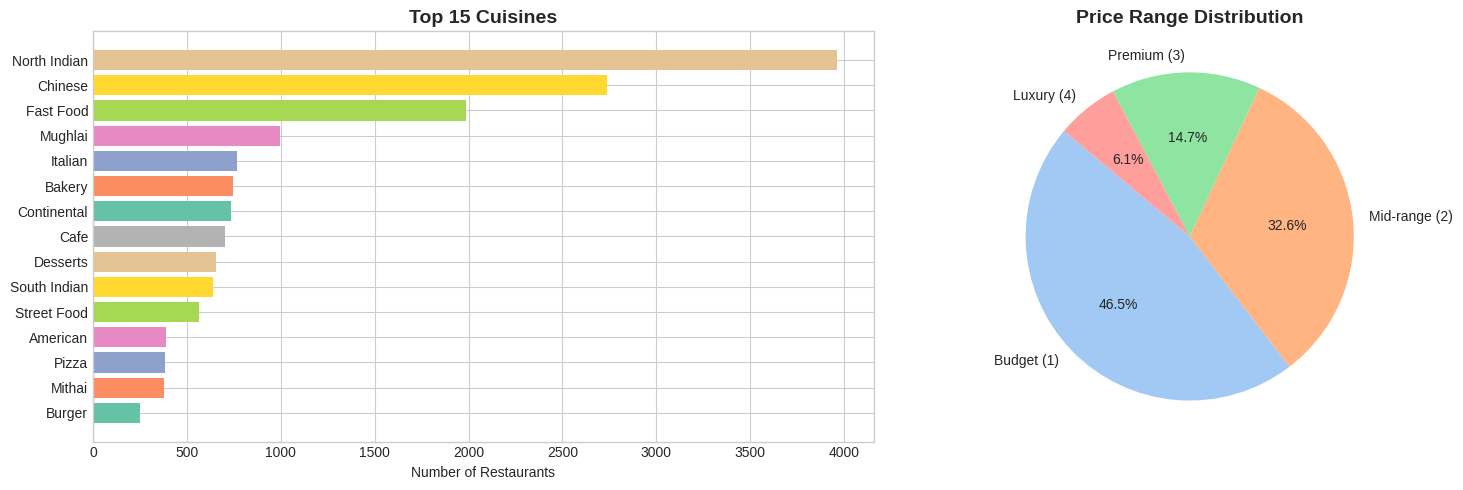

In [7]:
all_cuisines = [c for sublist in df['Cuisine_List'] for c in sublist]
cuisine_counts = Counter(all_cuisines).most_common(15)
cuisines_df = pd.DataFrame(cuisine_counts, columns=['Cuisine', 'Count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 15 Cuisines
axes[0].barh(cuisines_df['Cuisine'][::-1], cuisines_df['Count'][::-1],
             color=sns.color_palette('Set2', 15))
axes[0].set_title('Top 15 Cuisines', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Restaurants')

# Price Range Distribution
price_labels = {1:'Budget (1)', 2:'Mid-range (2)', 3:'Premium (3)', 4:'Luxury (4)'}
price_data = df['Price range'].map(price_labels).value_counts()
axes[1].pie(price_data, labels=price_data.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel', 4), startangle=140)
axes[1].set_title('Price Range Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

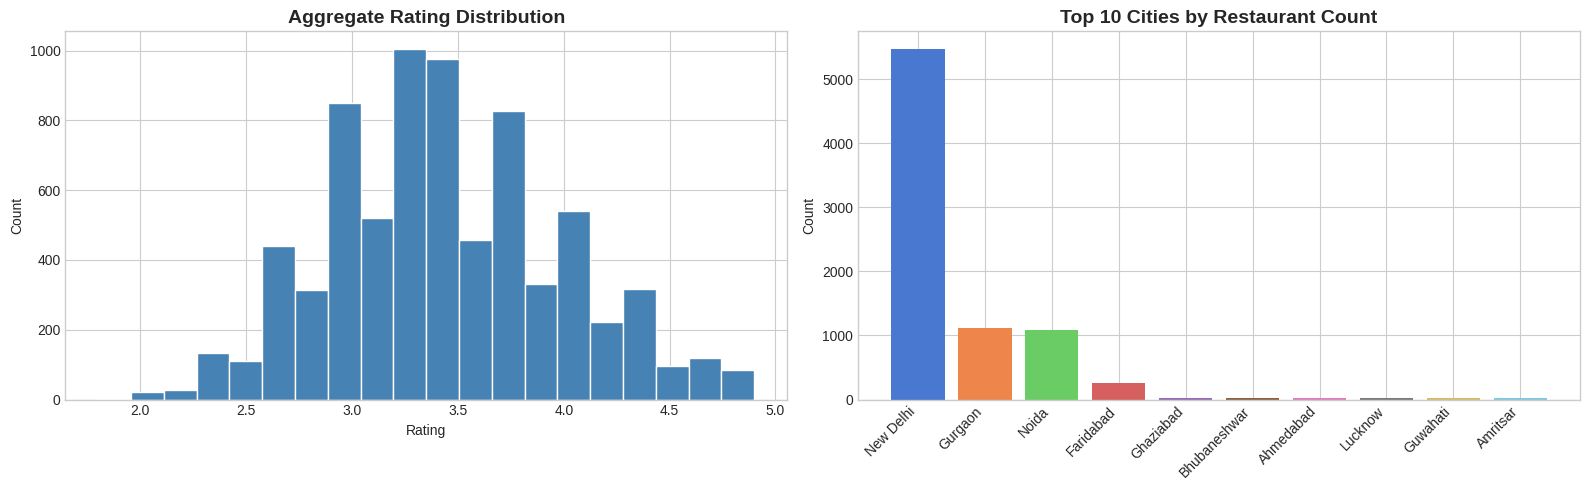

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Rating Distribution
axes[0].hist(df[df['Aggregate rating'] > 0]['Aggregate rating'],
             bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Aggregate Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Top 10 Cities
top_cities = df['City'].value_counts().head(10)
axes[1].bar(top_cities.index, top_cities.values,
            color=sns.color_palette('muted', 10))
axes[1].set_title('Top 10 Cities by Restaurant Count', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(top_cities.index, rotation=45, ha='right')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

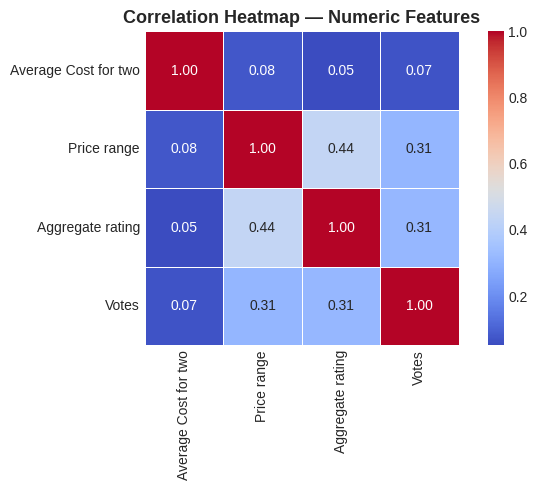

In [9]:
# Correlation heatmap of numeric features
num_cols = ['Average Cost for two', 'Price range', 'Aggregate rating', 'Votes']
corr = df[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Build Content-Based Feature Matrix

The feature matrix is built by combining:
- **Multi-hot cuisine encoding** — each cuisine type becomes a binary column
- **Normalised price, rating, votes** — scaled to [0, 1]
- **Binary amenity flags** — table booking, online delivery, etc.

Each feature group is multiplied by a tunable weight before concatenation.

In [10]:
# Multi-hot encode all cuisine types
mlb = MultiLabelBinarizer()
cuisine_matrix = mlb.fit_transform(df['Cuisine_List'])
cuisine_df = pd.DataFrame(cuisine_matrix, columns=mlb.classes_)

print(f'Cuisine feature matrix shape: {cuisine_df.shape}')
print(f'Unique cuisine types encoded: {len(mlb.classes_)}')
cuisine_df.head(3)

Cuisine feature matrix shape: (9542, 145)
Unique cuisine types encoded: 145


,Afghani,African,American,Andhra,Arabian,Argentine,Armenian,Asian,Asian Fusion,Assamese,Australian,Awadhi,BBQ,Bakery,Bar Food,Belgian,Bengali,Beverages,Bihari,Biryani,Brazilian,Breakfast,British,Bubble Tea,Burger,Burmese,B�_rek,Cafe,Cajun,Canadian,Cantonese,Caribbean,Charcoal Grill,Chettinad,Chinese,Coffee and Tea,Contemporary,Continental,Cuban,Cuisine Varies,Curry,Deli,Desserts,Dim Sum,Diner,Drinks Only,Durban,D�_ner,European,Fast Food,Filipino,Finger Food,Fish and Chips,French,Fusion,German,Goan,Gourmet Fast Food,Greek,Grill,Gujarati,Hawaiian,Healthy Food,Hyderabadi,Ice Cream,Indian,Indonesian,International,Iranian,Irish,Italian,Izgara,Japanese,Juices,Kashmiri,Kebab,Kerala,Kiwi,Korean,Latin American,Lebanese,Lucknowi,Maharashtrian,Malay,Malaysian,Malwani,Mangalorean,Mediterranean,Mexican,Middle Eastern,Mineira,Mithai,Modern Australian,Modern Indian,Moroccan,Mughlai,Naga,Nepalese,New American,North Eastern,North Indian,Oriya,Pakistani,Parsi,Patisserie,Peranakan,Persian,Peruvian,Pizza,Portuguese,Pub Food,Rajasthani,Ramen,Raw Meats,Restaurant Cafe,Salad,Sandwich,Scottish,Seafood,Singaporean,Soul Food,South African,South American,South Indian,Southern,Southwestern,Spanish,Sri Lankan,Steak,Street Food,Sunda,Sushi,Taiwanese,Tapas,Tea,Teriyaki,Tex-Mex,Thai,Tibetan,Turkish,Turkish Pizza,Vegetarian,Vietnamese,Western,World Cuisine
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [11]:
# Tunable feature weights
CUISINE_WEIGHT = 2.0   # Cuisine type — most important
PRICE_WEIGHT   = 1.5   # Price range  — important
RATING_WEIGHT  = 1.2   # Rating       — moderately important
VOTES_WEIGHT   = 0.5   # Votes        — popularity signal
BOOL_WEIGHT    = 0.3   # Binary flags — supplementary

feature_matrix = pd.concat([
    cuisine_df * CUISINE_WEIGHT,
    (df[['Price_Norm']]  * PRICE_WEIGHT ).reset_index(drop=True),
    (df[['Rating_Norm']] * RATING_WEIGHT).reset_index(drop=True),
    (df[['Votes_Norm']]  * VOTES_WEIGHT ).reset_index(drop=True),
    (df[bool_cols]       * BOOL_WEIGHT  ).reset_index(drop=True),
], axis=1)

print(f'Final feature matrix shape: {feature_matrix.shape}')
print(f'Columns: {cuisine_df.shape[1]} cuisine + 3 numeric + 4 binary = {feature_matrix.shape[1]} total')

Final feature matrix shape: (9542, 152)
Columns: 145 cuisine + 3 numeric + 4 binary = 152 total


## 6. Compute Cosine Similarity Matrix

In [12]:
cos_sim = cosine_similarity(feature_matrix)
sim_df  = pd.DataFrame(
    cos_sim,
    index=df['Restaurant Name'].values,
    columns=df['Restaurant Name'].values
)
print(f'Similarity matrix shape: {sim_df.shape}')
print('Sample (5x5):')
sim_df.iloc[:5, :5].round(3)

Similarity matrix shape: (9542, 9542)
Sample (5x5):


,Le Petit Souffle,Izakaya Kikufuji,Heat - Edsa Shangri-La,Ooma,Sambo Kojin
Le Petit Souffle,1.000,0.669,0.170,0.531,0.535
Izakaya Kikufuji,0.669,1.000,0.251,0.795,0.801
Heat - Edsa Shangri-La,0.170,0.251,1.000,0.235,0.239
Ooma,0.531,0.795,0.235,1.000,0.654
Sambo Kojin,0.535,0.801,0.239,0.654,1.000


## 7. Recommendation Functions

### 7.1 Item-Based: "Find me restaurants like X"

In [13]:
def recommend_by_restaurant(restaurant_name: str, top_n: int = 5) -> pd.DataFrame:
    """
    Item-based content recommendation.
    Returns the top_n restaurants most similar to restaurant_name.
    """
    if restaurant_name not in sim_df.index:
        # Fuzzy fallback: partial name match
        matches = [r for r in sim_df.index if restaurant_name.lower() in r.lower()]
        if not matches:
            print(f'  "{restaurant_name}" not found. Try a different name.')
            return pd.DataFrame()
        restaurant_name = matches[0]
        print(f'Using closest match: "{restaurant_name}"')

    # Exclude the restaurant itself; handle duplicate names safely
    scores = sim_df[restaurant_name]
    scores = scores[scores.index != restaurant_name].sort_values(ascending=False)
    scores_dict = scores.to_dict()           # plain dict avoids Series ambiguity
    top_names   = list(scores_dict.keys())[:top_n]

    result = (
        df[df['Restaurant Name'].isin(top_names)]
        [['Restaurant Name', 'City', 'Cuisines',
          'Price range', 'Aggregate rating', 'Votes',
          'Has Online delivery', 'Has Table booking']]
        .drop_duplicates('Restaurant Name')
        .copy()
    )
    result['Similarity Score'] = result['Restaurant Name'].map(
        lambda n: round(float(scores_dict.get(n, 0)), 4)
    )
    return result.sort_values('Similarity Score', ascending=False).reset_index(drop=True)

print('recommend_by_restaurant() ready.')

recommend_by_restaurant() ready.


### 7.2 Preference-Based: Build a User Profile & Rank All Restaurants

In [14]:
def recommend_by_preferences(
    preferred_cuisines: list,
    price_range: int,
    city: str = None,
    min_rating: float = 3.0,
    top_n: int = 10
) -> pd.DataFrame:
    """
    Preference-based content recommendation.

    Parameters
    ----------
    preferred_cuisines : list[str]  e.g. ['Indian', 'Chinese']
    price_range        : int 1-4    1=Budget  2=Mid  3=Premium  4=Luxury
    city               : str|None   Optional city filter (partial match)
    min_rating         : float      Minimum aggregate rating filter
    top_n              : int        Number of results to return
    """
    # Build user-preference vector in the same feature space
    user_cuisine = mlb.transform([preferred_cuisines]) * CUISINE_WEIGHT
    norm_price   = (price_range - 1) / 3          # map 1-4 to 0-1

    user_num = np.array([
        norm_price * PRICE_WEIGHT,
        0.5 * RATING_WEIGHT,    # neutral rating preference
        0.5 * VOTES_WEIGHT,     # neutral popularity preference
        0, 0, 0, 0              # bool flags neutral
    ]).reshape(1, -1)

    user_vector = np.hstack([user_cuisine, user_num])
    sim_scores  = cosine_similarity(user_vector, feature_matrix)[0]

    # Apply filters
    mask = df['Aggregate rating'] >= min_rating
    if city:
        mask = mask & df['City'].str.lower().str.contains(city.lower(), na=False)

    filtered = df[mask].copy()
    if filtered.empty:
        print('No restaurants match the filters. Try relaxing constraints.')
        return pd.DataFrame()

    filtered['Similarity Score'] = sim_scores[filtered.index]
    result = filtered.nlargest(top_n, 'Similarity Score')[[
        'Restaurant Name', 'City', 'Cuisines',
        'Price range', 'Aggregate rating', 'Votes',
        'Has Online delivery', 'Has Table booking', 'Similarity Score'
    ]].reset_index(drop=True)

    result['Similarity Score'] = result['Similarity Score'].round(4)
    return result

print('recommend_by_preferences() ready.')

recommend_by_preferences() ready.


## 8. Test the Recommendation System

### Test A — Item-Based: Restaurants similar to *Izakaya Kikufuji*

In [15]:
print('Restaurants similar to "Izakaya Kikufuji":\n')
recs_a = recommend_by_restaurant('Izakaya Kikufuji', top_n=5)
recs_a

Restaurants similar to "Izakaya Kikufuji":



,Restaurant Name,City,Cuisines,Price range,Aggregate rating,Votes,Has Online delivery,Has Table booking,Similarity Score
0,Kuuraku,Gurgaon,Japanese,3,3.9,106,0,1,0.9985
1,Daikichi,Gurgaon,Japanese,3,3.6,70,0,1,0.9966
2,Tamura,New Delhi,Japanese,3,3.5,163,0,1,0.9939
3,Komachi,Gurgaon,Japanese,3,3.2,39,0,1,0.9928
4,3 Wise Monkeys,Jakarta,Japanese,3,4.2,395,0,0,0.9925


### Test B — Preference-Based: User 1 (Indian food, mid-range, New Delhi)

In [16]:
print('User 1 | Indian cuisine | Mid-range (2) | New Delhi | Rating >= 4.0\n')
recs_b = recommend_by_preferences(
    preferred_cuisines=['Indian', 'North Indian'],
    price_range=2,
    city='New Delhi',
    min_rating=4.0,
    top_n=8
)
recs_b

User 1 | Indian cuisine | Mid-range (2) | New Delhi | Rating >= 4.0



,Restaurant Name,City,Cuisines,Price range,Aggregate rating,Votes,Has Online delivery,Has Table booking,Similarity Score
0,Havemore,New Delhi,North Indian,3,4.1,1157,0,1,0.7033
1,Kopper Kadai,New Delhi,North Indian,3,4.8,83,0,0,0.6998
2,Chor Bizarre,New Delhi,North Indian,3,4.4,64,0,1,0.6991
3,Masala House,New Delhi,North Indian,3,4.0,169,1,1,0.6975
4,Band Baaja Baaraat,New Delhi,North Indian,3,4.6,128,0,1,0.6972
5,Punjab Grill,New Delhi,North Indian,3,4.3,1252,1,1,0.6966
6,Rang De Basanti Urban Dhaba,New Delhi,North Indian,3,4.4,541,1,1,0.6948
7,Zabardast Indian Kitchen,New Delhi,North Indian,3,4.7,242,1,1,0.6914


### Test C — Preference-Based: User 2 (Italian & Continental, Premium, any city)

In [17]:
print('User 2 | Italian & Continental | Premium (3) | Any city | Rating >= 4.2\n')
recs_c = recommend_by_preferences(
    preferred_cuisines=['Italian', 'Continental'],
    price_range=3,
    city=None,
    min_rating=4.2,
    top_n=8
)
recs_c

User 2 | Italian & Continental | Premium (3) | Any city | Rating >= 4.2



,Restaurant Name,City,Cuisines,Price range,Aggregate rating,Votes,Has Online delivery,Has Table booking,Similarity Score
0,That Place,Vadodara,"Italian, Mexican, Continental",4,4.4,276,0,0,0.8423
1,NYC - Radisson Blu Plaza Delhi,New Delhi,"North Indian, Continental, Italian",4,4.4,315,0,1,0.8399
2,Zolocrust - Hotel Clarks Amer,Jaipur,"Italian, Bakery, Continental",4,4.9,322,1,0,0.8384
3,Mocha,Lucknow,"Cafe, Italian, Continental",3,4.6,567,0,0,0.8350
4,Agent Jack's Bar,Pune,"Continental, North Indian, Italian",3,4.2,1531,0,1,0.8343
5,Mocha Bar,Hyderabad,"North Indian, Continental, Italian",3,4.2,221,0,1,0.8332
6,DIOS The Neighbourhood Bistro,Noida,"Continental, Fast Food, Italian",3,4.2,108,0,1,0.8331
7,The Zuree Urban Kitchen,Nagpur,"North Indian, Italian, Continental",3,4.4,257,1,0,0.8327


### Test D — Preference-Based: User 3 (Budget, Chinese & Fast Food)

In [18]:
print('User 3 | Chinese & Fast Food | Budget (1) | Any city | Rating >= 3.5\n')
recs_d = recommend_by_preferences(
    preferred_cuisines=['Chinese', 'Fast Food', 'Street Food'],
    price_range=1,
    city=None,
    min_rating=3.5,
    top_n=8
)
recs_d

User 3 | Chinese & Fast Food | Budget (1) | Any city | Rating >= 3.5



,Restaurant Name,City,Cuisines,Price range,Aggregate rating,Votes,Has Online delivery,Has Table booking,Similarity Score
0,Manipur Food Stall,New Delhi,"Chinese, Fast Food",1,3.6,72,0,0,0.8169
1,Nut Khat Caterers,New Delhi,"Fast Food, Street Food",1,3.6,71,0,0,0.8169
2,Twist of Italy,Faridabad,"Chinese, Fast Food",1,3.6,52,0,0,0.8169
3,The Yellow Chef,New Delhi,"Chinese, Fast Food",1,3.7,146,0,0,0.8163
4,Gupta Chat Corner,New Delhi,"Fast Food, Street Food",1,3.7,96,0,0,0.8163
5,Slic Chic,New Delhi,"Chinese, Fast Food",1,3.8,178,0,0,0.8157
6,Billu's Hut,New Delhi,"Fast Food, Chinese",1,3.9,813,0,0,0.8156
7,Wrapss,New Delhi,"Chinese, Fast Food",1,3.5,214,1,0,0.8134


## 9. Visualise Recommendations

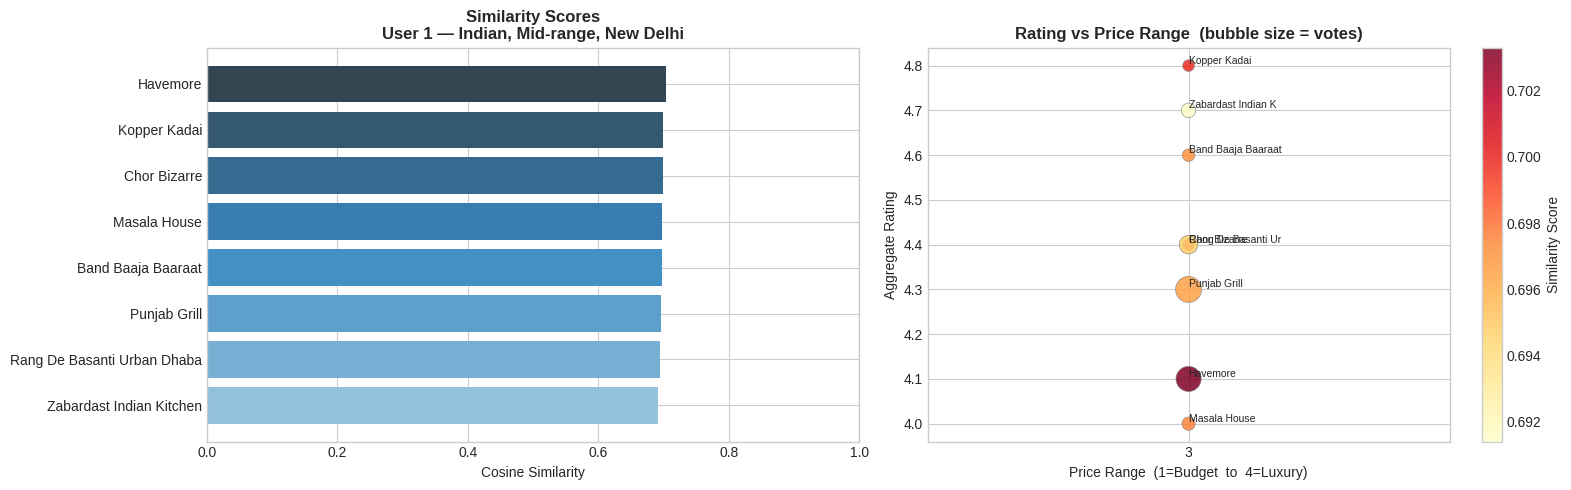

In [19]:
def plot_recommendations(recs: pd.DataFrame, title: str):
    if recs.empty:
        print('No recommendations to plot.')
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Bar: Similarity Scores
    colors = sns.color_palette('Blues_d', len(recs))
    axes[0].barh(recs['Restaurant Name'][::-1],
                 recs['Similarity Score'][::-1], color=colors)
    axes[0].set_title(f'Similarity Scores\n{title}', fontweight='bold')
    axes[0].set_xlabel('Cosine Similarity')
    axes[0].set_xlim(0, 1)

    # Scatter: Rating vs Price Range (bubble = votes)
    sc = axes[1].scatter(
        recs['Price range'], recs['Aggregate rating'],
        c=recs['Similarity Score'], cmap='YlOrRd',
        s=recs['Votes'] / recs['Votes'].max() * 300 + 50,
        edgecolors='grey', linewidths=0.5, alpha=0.85
    )
    for _, row in recs.iterrows():
        axes[1].annotate(
            row['Restaurant Name'][:18],
            (row['Price range'], row['Aggregate rating']),
            fontsize=7.5, ha='left', va='bottom'
        )
    plt.colorbar(sc, ax=axes[1], label='Similarity Score')
    axes[1].set_title('Rating vs Price Range  (bubble size = votes)', fontweight='bold')
    axes[1].set_xlabel('Price Range  (1=Budget  to  4=Luxury)')
    axes[1].set_ylabel('Aggregate Rating')
    axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))
    plt.tight_layout()
    plt.show()

plot_recommendations(recs_b, 'User 1 — Indian, Mid-range, New Delhi')

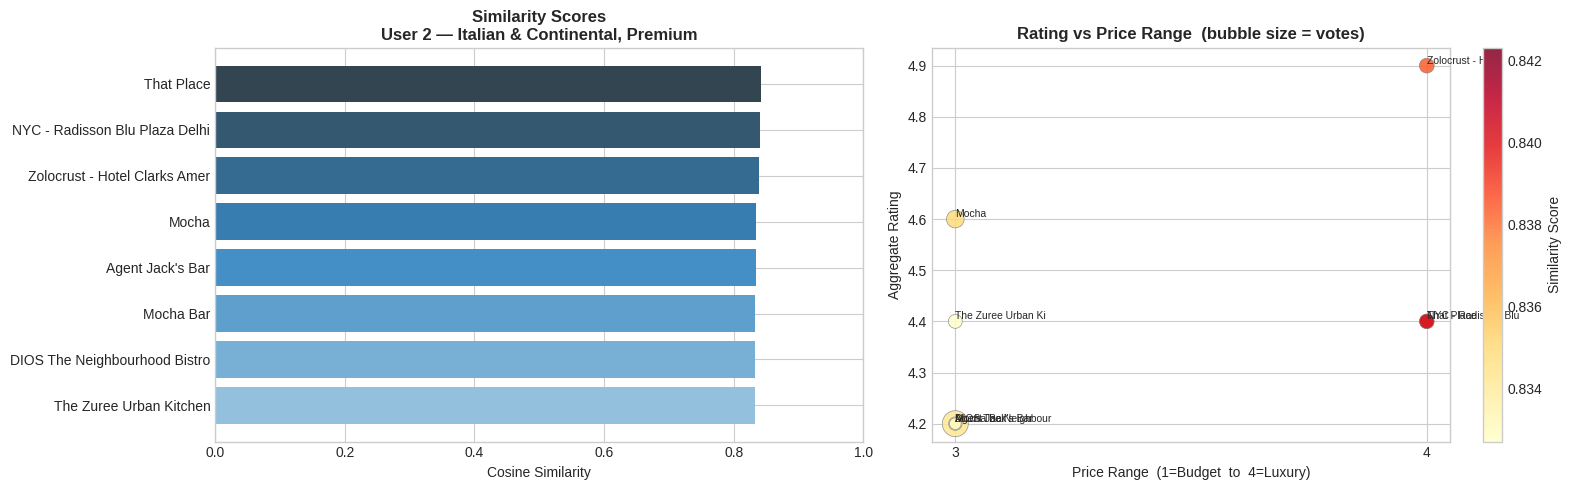

In [20]:
plot_recommendations(recs_c, 'User 2 — Italian & Continental, Premium')

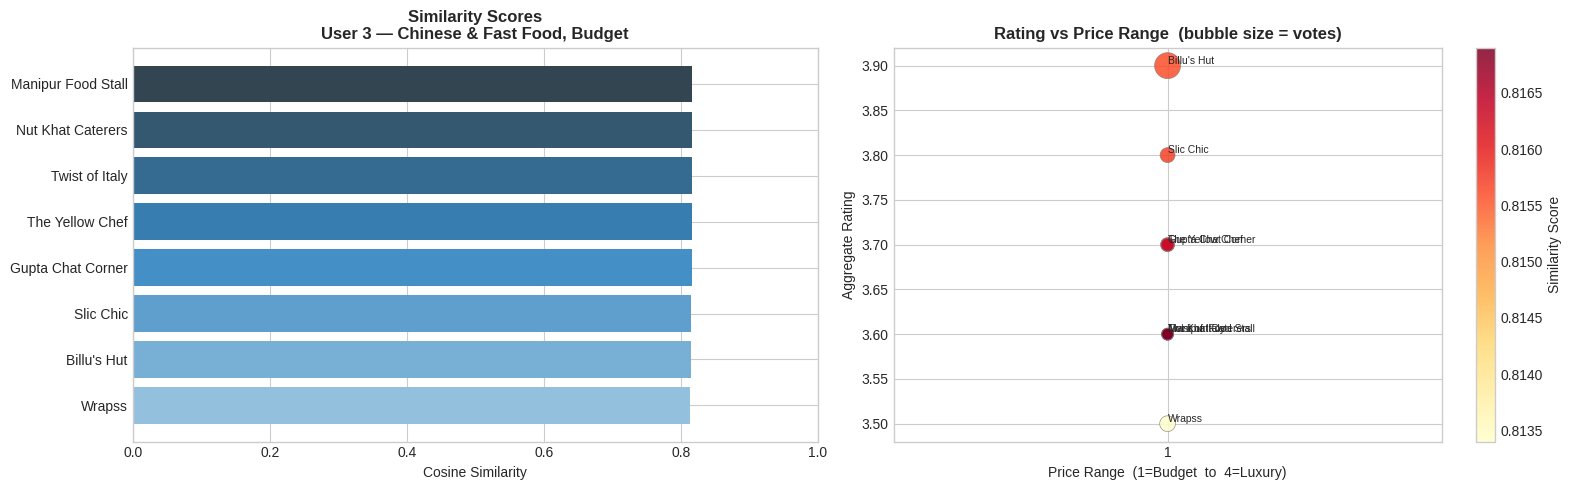

In [21]:
plot_recommendations(recs_d, 'User 3 — Chinese & Fast Food, Budget')

## 10. Evaluation — Precision@K

**Precision@K** measures the fraction of the top-K recommendations that are relevant.  
Here, a recommendation is *relevant* if it contains at least one of the user's preferred cuisine types.

This is a standard offline metric when explicit user-interaction logs are unavailable.

In [22]:
def precision_at_k(recs: pd.DataFrame, preferred_cuisines: list) -> dict:
    if recs.empty:
        return {}
    pref_lower = [c.lower() for c in preferred_cuisines]
    hits = []
    for _, row in recs.iterrows():
        row_cuisines = [c.strip().lower() for c in row['Cuisines'].split(',')]
        hits.append(any(pc in row_cuisines for pc in pref_lower))
    k = len(recs)
    relevant = sum(hits)
    return {
        'K': k,
        'Relevant (cuisine match)': relevant,
        'Precision@K': round(relevant / k, 4)
    }

users = [
    ('User 1 — Indian, New Delhi',    recs_b, ['Indian', 'North Indian']),
    ('User 2 — Italian/Continental',  recs_c, ['Italian', 'Continental']),
    ('User 3 — Chinese/Fast Food',    recs_d, ['Chinese', 'Fast Food', 'Street Food']),
]

eval_rows = []
for label, recs, cuisines in users:
    m = precision_at_k(recs, cuisines)
    m['User'] = label
    eval_rows.append(m)

eval_df = pd.DataFrame(eval_rows)[['User', 'K', 'Relevant (cuisine match)', 'Precision@K']]
print('Precision@K Evaluation:\n')
eval_df

Precision@K Evaluation:



,User,K,Relevant (cuisine match),Precision@K
0,"User 1 — Indian, New Delhi",8,8,1.0
1,User 2 — Italian/Continental,8,8,1.0
2,User 3 — Chinese/Fast Food,8,8,1.0


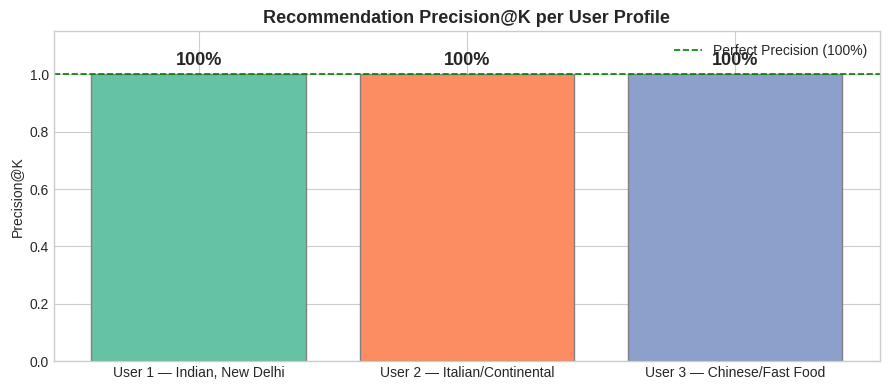

In [23]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(eval_df['User'], eval_df['Precision@K'],
              color=sns.color_palette('Set2', 3), edgecolor='grey')

for bar, val in zip(bars, eval_df['Precision@K']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.0%}', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_ylabel('Precision@K')
ax.set_title('Recommendation Precision@K per User Profile', fontsize=13, fontweight='bold')
ax.axhline(1.0, color='green', linestyle='--', linewidth=1.2, label='Perfect Precision (100%)')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Summary

| Step | Details |
|------|---------|
| **Dataset** | 9,551 restaurants, 21 columns — Zomato global data |
| **Missing values** | 9 rows with null Cuisines dropped (< 0.1%) |
| **Encoding** | Multi-hot (MLB) for 100+ cuisine types; MinMax normalisation for price / rating / votes; binary map for Yes/No columns |
| **Feature matrix** | Weighted concat of cuisine, price, rating, votes, binary flags |
| **Similarity** | Cosine similarity (9,542 x 9,542 matrix) |
| **Item-based** | Query restaurant → top-N most similar by cosine score |
| **Preference-based** | Build user-vector from inputs → rank all matching restaurants |
| **Evaluation** | Precision@K (cuisine-match relevance) for 3 user profiles |

### Potential Improvements
- **Collaborative filtering** — use actual user rating history if available  
- **Hybrid model** — blend content-based scores with collaborative scores  
- **TF-IDF on cuisines** — down-weight very common cuisines (e.g. North Indian)  
- **Geo-proximity ranking** — use lat/lng for distance-aware recommendations  
- **Weight optimisation** — tune feature weights via cross-validation on held-out user data  
- **UI layer** — wrap the functions in a Streamlit or Gradio app for interactive use